In [1]:
# Import modules
%matplotlib inline
import os, sys
base_dir = "../../"
sys.path.extend([f"{base_dir}/postprocess"])
import numpy as np
import xarray as xr

# for plotting
#from jupyter_plotting import *
from plotting import *




 # Line plot

#### add config either with the dictionary or directly as an argument to the instance of Config

In [2]:
#config parameters
config = {}
config['base_folder'] = "/p/scratch/deepacf/maelstrom/maelstrom_data/ap5/downscaling_benchmark_dataset/benchmark_t2m/results"
config['variable'] = "t2m"
config['models'] = ["deepru","sha_unet","sha_wgan","swinir"]
config['seasons'] = "year"   #["year","DJF","JJA","MAM","SON"]
config['metric'] = "rmse" #["bias","grad_amplitude","me_std","rmse"]                     
                                      

In [3]:
config = Config(**config)

### Define the metric unit and create a dictionary of it. These is being used in labeling the y-axis

In [4]:
#define metric
metric_name = f'{config.metric} {config.variable}' 
metric_unit = "$^\circ$C"
metric_dict = {metric_name:metric_unit}

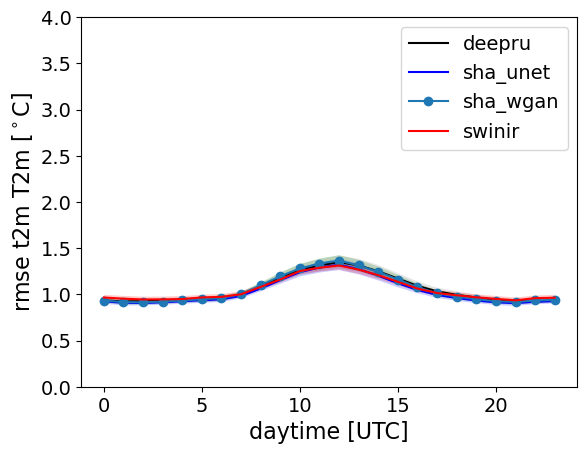

In [5]:
plot_metric_line(config,None,None,config.models,metric_dict,"metric_line",uncertainty=True)

# Box plot

In [8]:
#config parameters
config = {}
config['base_folder'] = "/p/scratch/deepacf/maelstrom/maelstrom_data/ap5/downscaling_benchmark_dataset/benchmark_t2m/results"
config['variable'] = "t2m"
config['models'] = ["deepru","sha_unet","sha_wgan","swinir"]
config['seasons'] = "year"   #["year","DJF","JJA","MAM","SON"]
config['metric'] = "grad_amplitude" #["bias","grad_amplitude","me_std","rmse"]                     
                                      

In [9]:
config = Config(**config)

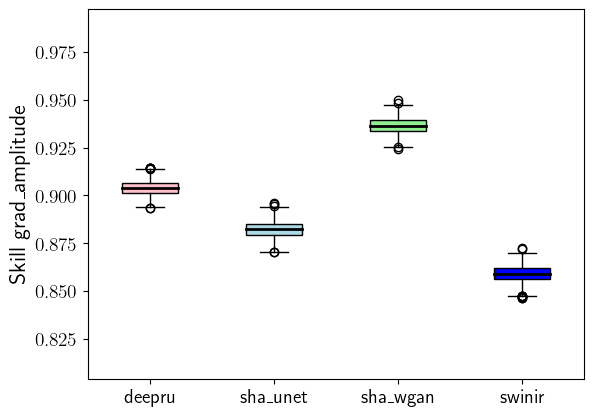

In [10]:
plot_skills(config,"box_plot",labels=config.models,metric=config.metric)

# Model Comparison

In [11]:
config = {}
config['base_folder'] = "/p/scratch/deepacf/maelstrom/maelstrom_data/ap5/downscaling_benchmark_dataset/benchmark_t2m/results"
config['variable'] = "t2m"
config['models'] = ["deepru","sha_unet","sha_wgan","swinir"]
config['seasons'] = "JJA"   #["year","DJF","JJA","MAM","SON"]
if config['seasons'] not in ["year","DJF","JJA","MAM","SON"]:
    raise ValueError("seasons should be one of [year, DJF, JJA, MAM, SON]")
config['metric'] = "rmse" #["bias","grad_amplitude","me_std","rmse"]                     
if config['metric'] not in ["bias","grad_amplitude","me_std","rmse"]:
    raise ValueError("metric should be one of [bias, grad_amplitude, me_std, rmse]")

In [12]:
config = Config(**config)

#### If you want to add specific month and/or data and/or hour, please define it in config.datetime otherwise by default it will show results for "config.seasons" parameter

In [15]:
config.datetime = {"month" : "Jul" , 
                   "date" : 31,
                   "hour" : 14}

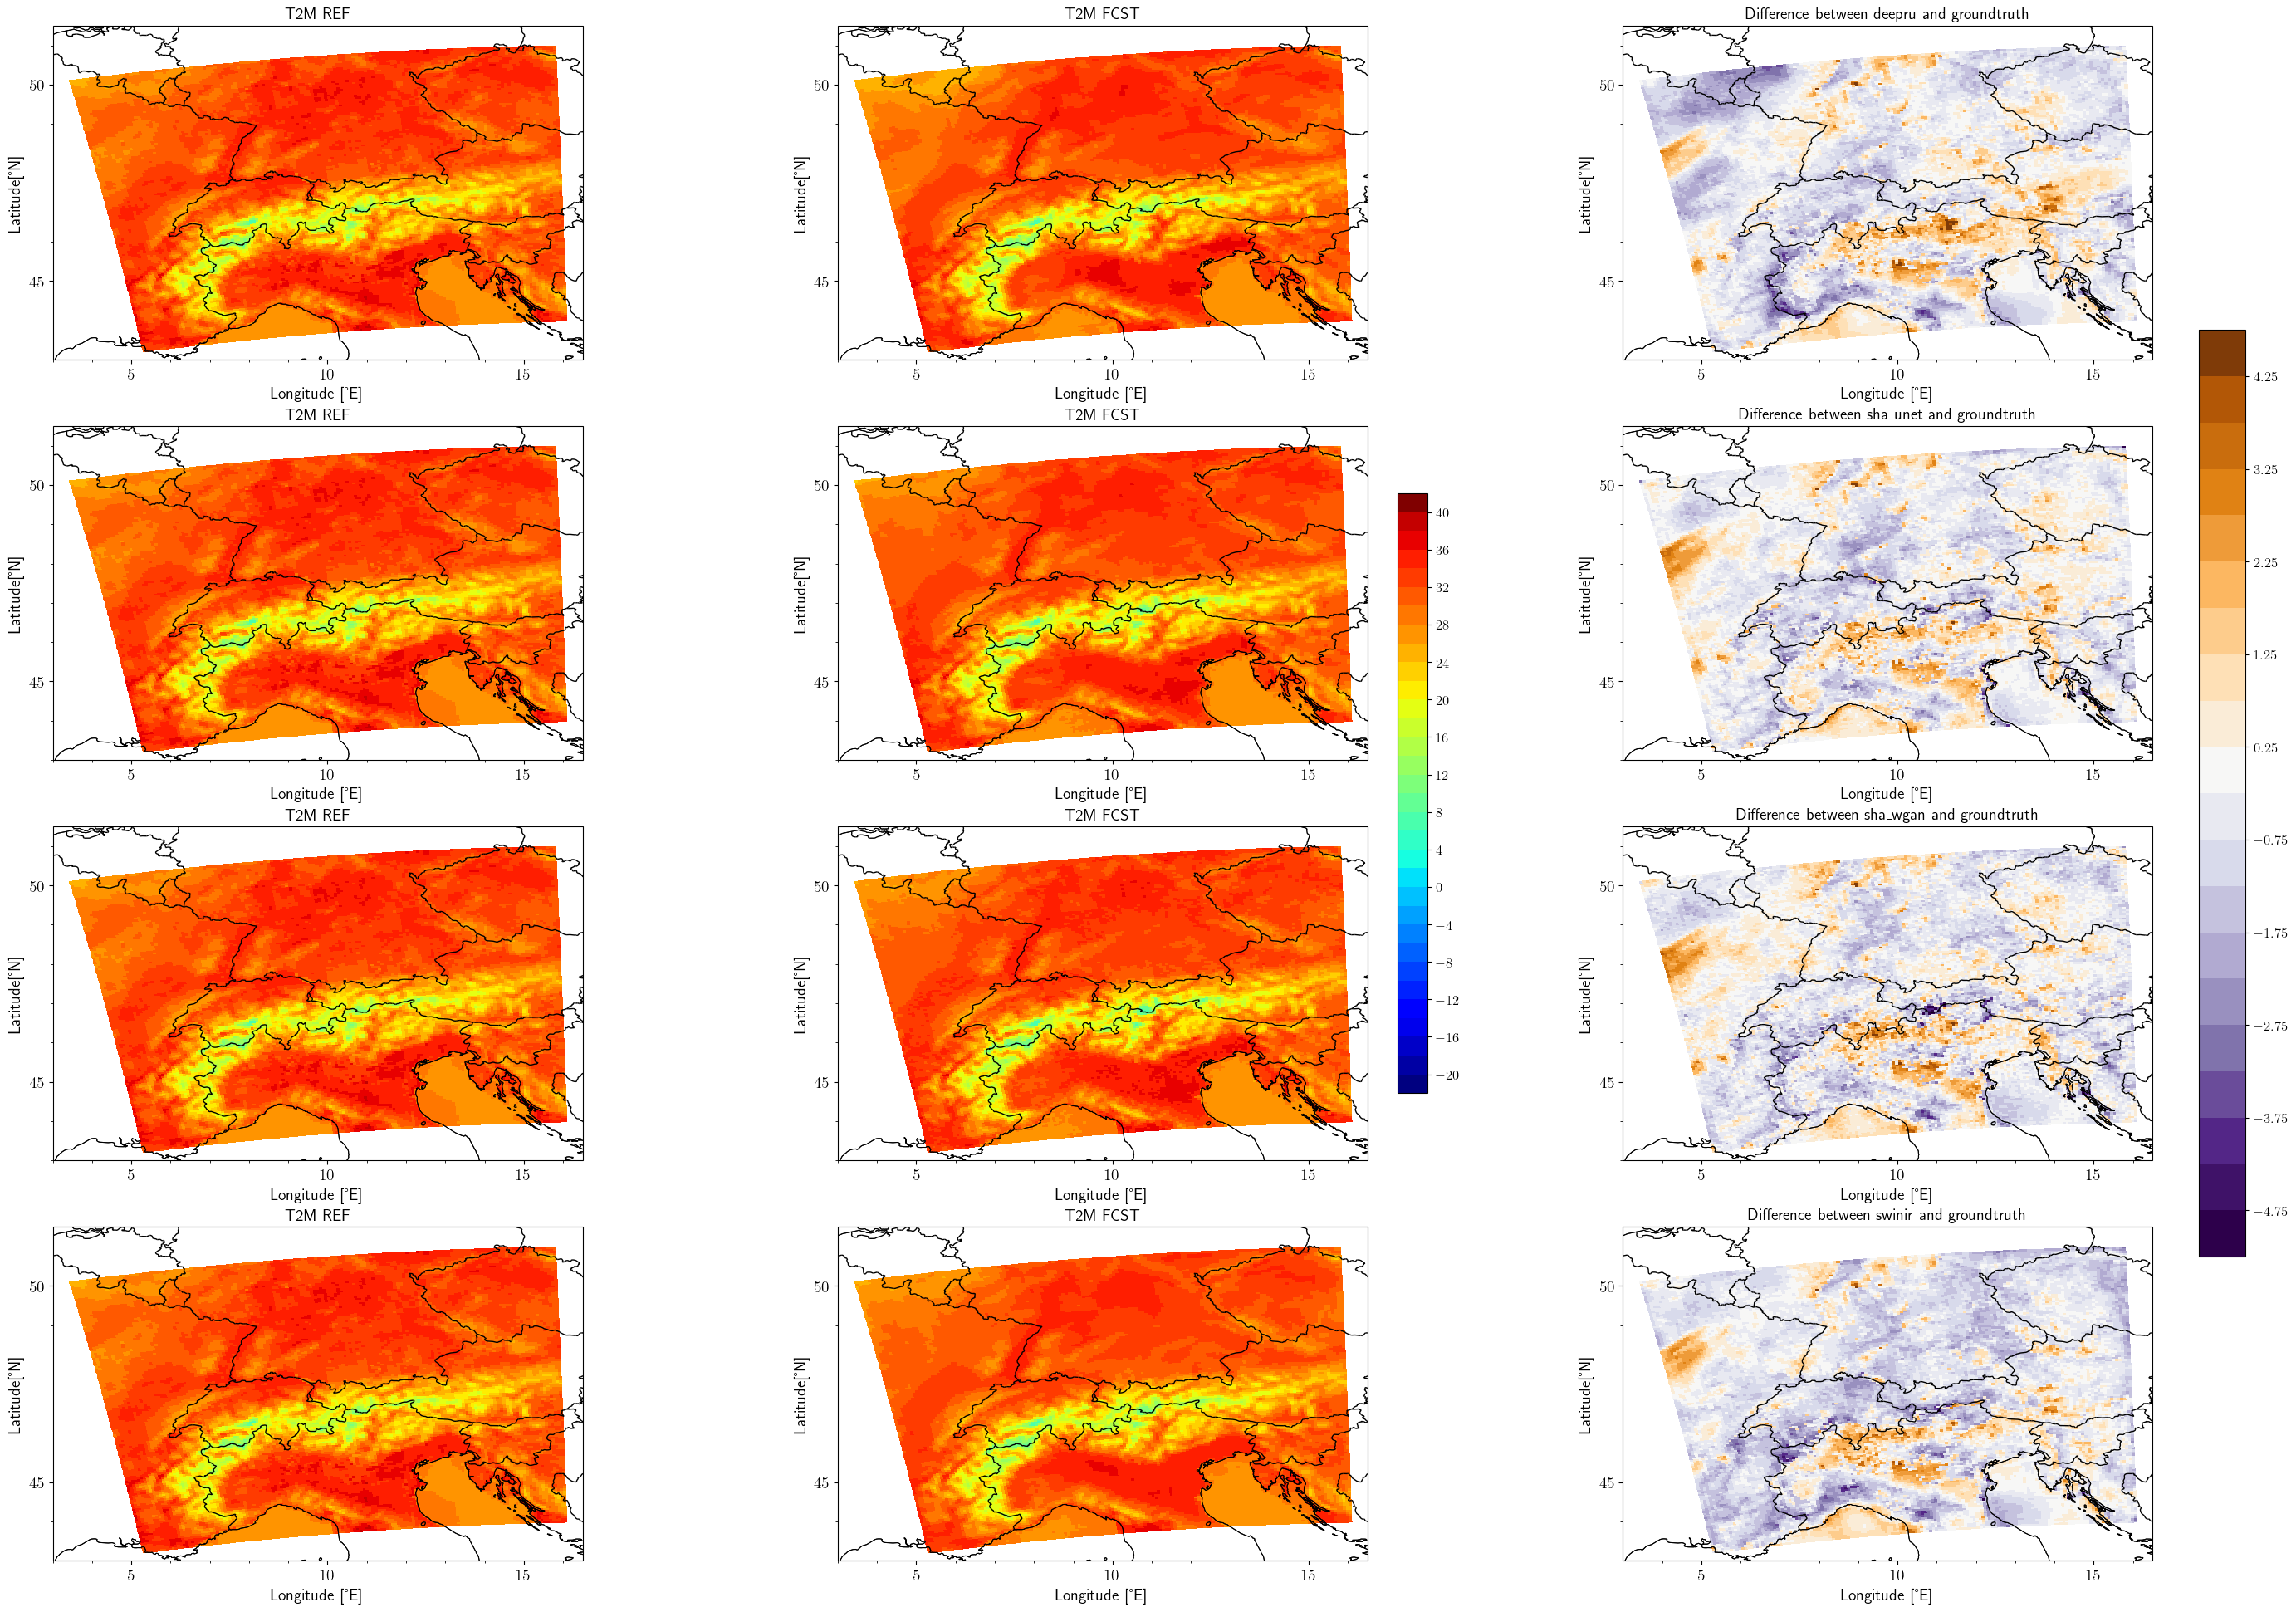

In [16]:
plot_comparison_maps(config,"compare_plot",show=True,save=False)

## Energy Spectra